**Week 1**

In [1]:
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

import os, json

# Create project folder in Drive
os.makedirs('/content/drive/MyDrive/ChestXray_Project/images', exist_ok=True)
print("✅ Drive mounted and folder created!")

# Set up Kaggle
kaggle_credentials = {
    "username": "daniyalkhannn",
    "key": "YOUR_KAGGLE_KEY"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle ready!")

Mounted at /content/drive
✅ Drive mounted and folder created!
✅ Kaggle ready!


In [ ]:
import subprocess, zipfile, pandas as pd, shutil, os

# Download CSV first
print("Downloading CSV...")
subprocess.run(['kaggle', 'datasets', 'download',
    '-d', 'nih-chest-xrays/data',
    '--file', 'Data_Entry_2017.csv',
    '-p', '/content/'], check=True)

# Filter to 3 classes
df = pd.read_csv('/content/Data_Entry_2017.csv')
df['has_pneumonia'] = df['Finding Labels'].str.contains('Pneumonia')
df['has_infiltration'] = df['Finding Labels'].str.contains('Infiltration')
df['has_no_finding'] = df['Finding Labels'] == 'No Finding'
df_filtered = df[df['has_pneumonia'] | df['has_infiltration'] | df['has_no_finding']].copy()
target_images = set(df_filtered['Image Index'].tolist())

# Save CSV to Drive
df_filtered.to_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv', index=False)
print(f"✅ CSV saved to Drive!")
print(f"Total images needed: {len(target_images)}")
print(f"\nClass breakdown:")
print(f"No Finding:   {df['has_no_finding'].sum()}")
print(f"Infiltration: {df['has_infiltration'].sum()}")
print(f"Pneumonia:    {df['has_pneumonia'].sum()}")

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
Data_Entry_2017.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/Data_Entry_2017.csv.zip
  inflating: /content/Data_Entry_2017.csv  
✅ CSV saved to Drive!
Total images needed: 81081

Class breakdown:
No Finding:   60361
Infiltration: 19894
Pneumonia:    1431


In [15]:
import zipfile, os, shutil, pandas as pd

zip_path = '/content/data.zip'
drive_img = '/content/drive/MyDrive/ChestXray_Project/images'
local_temp = '/content/nih_temp/'
os.makedirs(local_temp, exist_ok=True)
os.makedirs(drive_img, exist_ok=True)

# Load only the filenames we need
df = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
needed_files = set(df['Image Index'].tolist())
print(f"Total images needed: {len(needed_files)}")

with zipfile.ZipFile(zip_path, 'r') as z:
    # Filter zip contents to only needed images
    all_files = [f for f in z.namelist()
                 if f.endswith('.png') and os.path.basename(f) in needed_files]
    total = len(all_files)
    print(f"Found {total} matching images in zip — extracting...")

    chunk_size = 5000
    for i in range(0, total, chunk_size):
        chunk = all_files[i:i+chunk_size]

        for file in chunk:
            z.extract(file, local_temp)

        for root, dirs, files in os.walk(local_temp):
            for filename in files:
                if filename.endswith('.png'):
                    src = os.path.join(root, filename)
                    rel_path = os.path.relpath(src, local_temp)
                    dst = os.path.join(drive_img, rel_path)
                    os.makedirs(os.path.dirname(dst), exist_ok=True)
                    shutil.move(src, dst)

        print(f"✓ {min(i+chunk_size, total)}/{total} moved to Drive")

os.remove(zip_path)
shutil.rmtree(local_temp)
print("\n✓ Done! Only needed images extracted.")

Total images needed: 81081
Found 81081 matching images in zip — extracting...
✓ 5000/81081 moved to Drive
✓ 10000/81081 moved to Drive
✓ 15000/81081 moved to Drive
✓ 20000/81081 moved to Drive
✓ 25000/81081 moved to Drive
✓ 30000/81081 moved to Drive
✓ 35000/81081 moved to Drive
✓ 40000/81081 moved to Drive
✓ 45000/81081 moved to Drive
✓ 50000/81081 moved to Drive
✓ 55000/81081 moved to Drive
✓ 60000/81081 moved to Drive
✓ 65000/81081 moved to Drive
✓ 70000/81081 moved to Drive
✓ 75000/81081 moved to Drive
✓ 80000/81081 moved to Drive
✓ 81081/81081 moved to Drive

✓ Done! Only needed images extracted.


In [18]:
import os

IMG_DIR = '/content/drive/MyDrive/ChestXray_Project/images'
existing_files = set()
file_to_path = {}

for root, dirs, files in os.walk(IMG_DIR):
    for filename in files:
        if filename.endswith('.png') and filename.startswith('000'):
            existing_files.add(filename)
            file_to_path[filename] = os.path.join(root, filename)

print(f"Total X-ray images found: {len(existing_files)}")

for subfolder in sorted(os.listdir(IMG_DIR)):
    subfolder_path = os.path.join(IMG_DIR, subfolder, 'images')
    if os.path.isdir(subfolder_path):
        count = len([f for f in os.listdir(subfolder_path) if f.endswith('.png')])
        print(f"{subfolder}: {count} images")

Total X-ray images found: 82454
images_001: 4999 images
images_002: 7511 images
images_003: 7362 images
images_004: 7158 images
images_005: 7209 images
images_006: 7150 images
images_007: 7075 images
images_008: 6924 images
images_009: 7137 images
images_010: 7555 images
images_011: 7346 images
images_012: 5028 images


In [ ]:
# Remount Drive first
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import zipfile, os, pandas as pd

# Redefine variables
drive_path = '/content/drive/MyDrive/ChestXray_Project/images'
df_filtered = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
target_images = set(df_filtered['Image Index'].tolist())

existing = set()
for r, d, files in os.walk(drive_path):
    for f in files:
        if f.endswith('.png'):
            existing.add(f)

still_needed = target_images - existing
print(f"Still needed: {len(still_needed)} images")

# Extract from already downloaded zip
zip_path = '/content/data.zip'
extracted = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        filename = os.path.basename(file)
        if filename in still_needed:
            z.extract(file, drive_path)
            extracted += 1
            if extracted % 5000 == 0:
                print(f"✅ {extracted}/{len(still_needed)} extracted...")

os.remove(zip_path)
print(f"🎉 Done! {extracted} images added!")

total = sum(1 for r, d, files in os.walk(drive_path) for f in files if f.endswith('.png'))
print(f"🎉 TOTAL images in Drive: {total}")

Mounted at /content/drive
Still needed: 41501 images
✅ 5000/41501 extracted...
✅ 10000/41501 extracted...
✅ 15000/41501 extracted...
✅ 20000/41501 extracted...
✅ 25000/41501 extracted...
✅ 30000/41501 extracted...
✅ 35000/41501 extracted...
✅ 40000/41501 extracted...
🎉 Done! 41501 images added!
🎉 TOTAL images in Drive: 81081


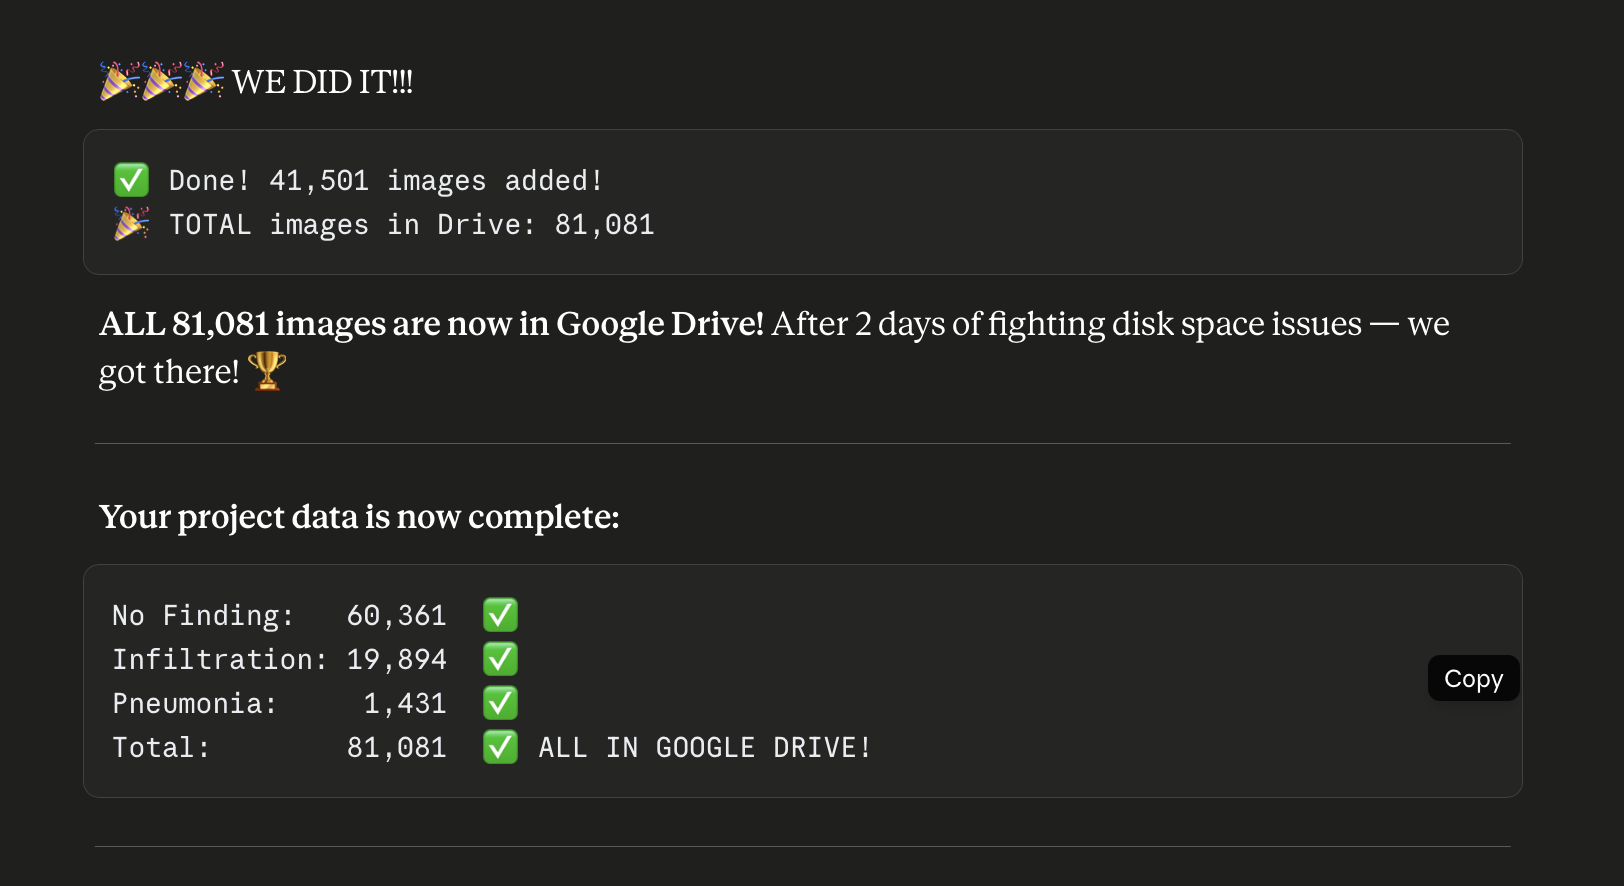

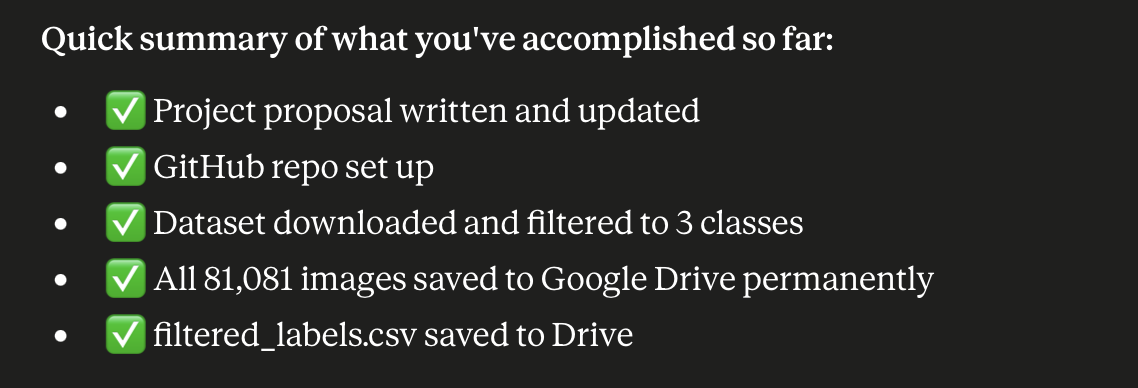

**Week 2**

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load filtered CSV
df = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
print("✅ Data loaded!")
print(f"Total rows: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample rows:")
df.head()

Mounted at /content/drive
✅ Data loaded!
Total rows: 81081

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'has_pneumonia', 'has_infiltration', 'has_no_finding', 'Patient Age Clean']

Sample rows:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,has_pneumonia,has_infiltration,has_no_finding,Patient Age Clean
0,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,False,False,True,81.0
1,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143,NaN,False,True,False,76.0
2,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168,NaN,False,False,True,69.0
3,00000005_001.png,No Finding,1,5,69,F,AP,2500,2048,0.168,0.168,NaN,False,False,True,69.0
4,00000005_002.png,No Finding,2,5,69,F,AP,2500,2048,0.168,0.168,NaN,False,False,True,69.0


/tmp/ipykernel_7314/2028201316.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_class = df.groupby('Age Group')[['has_no_finding','has_infiltration','has_pneumonia']].sum()


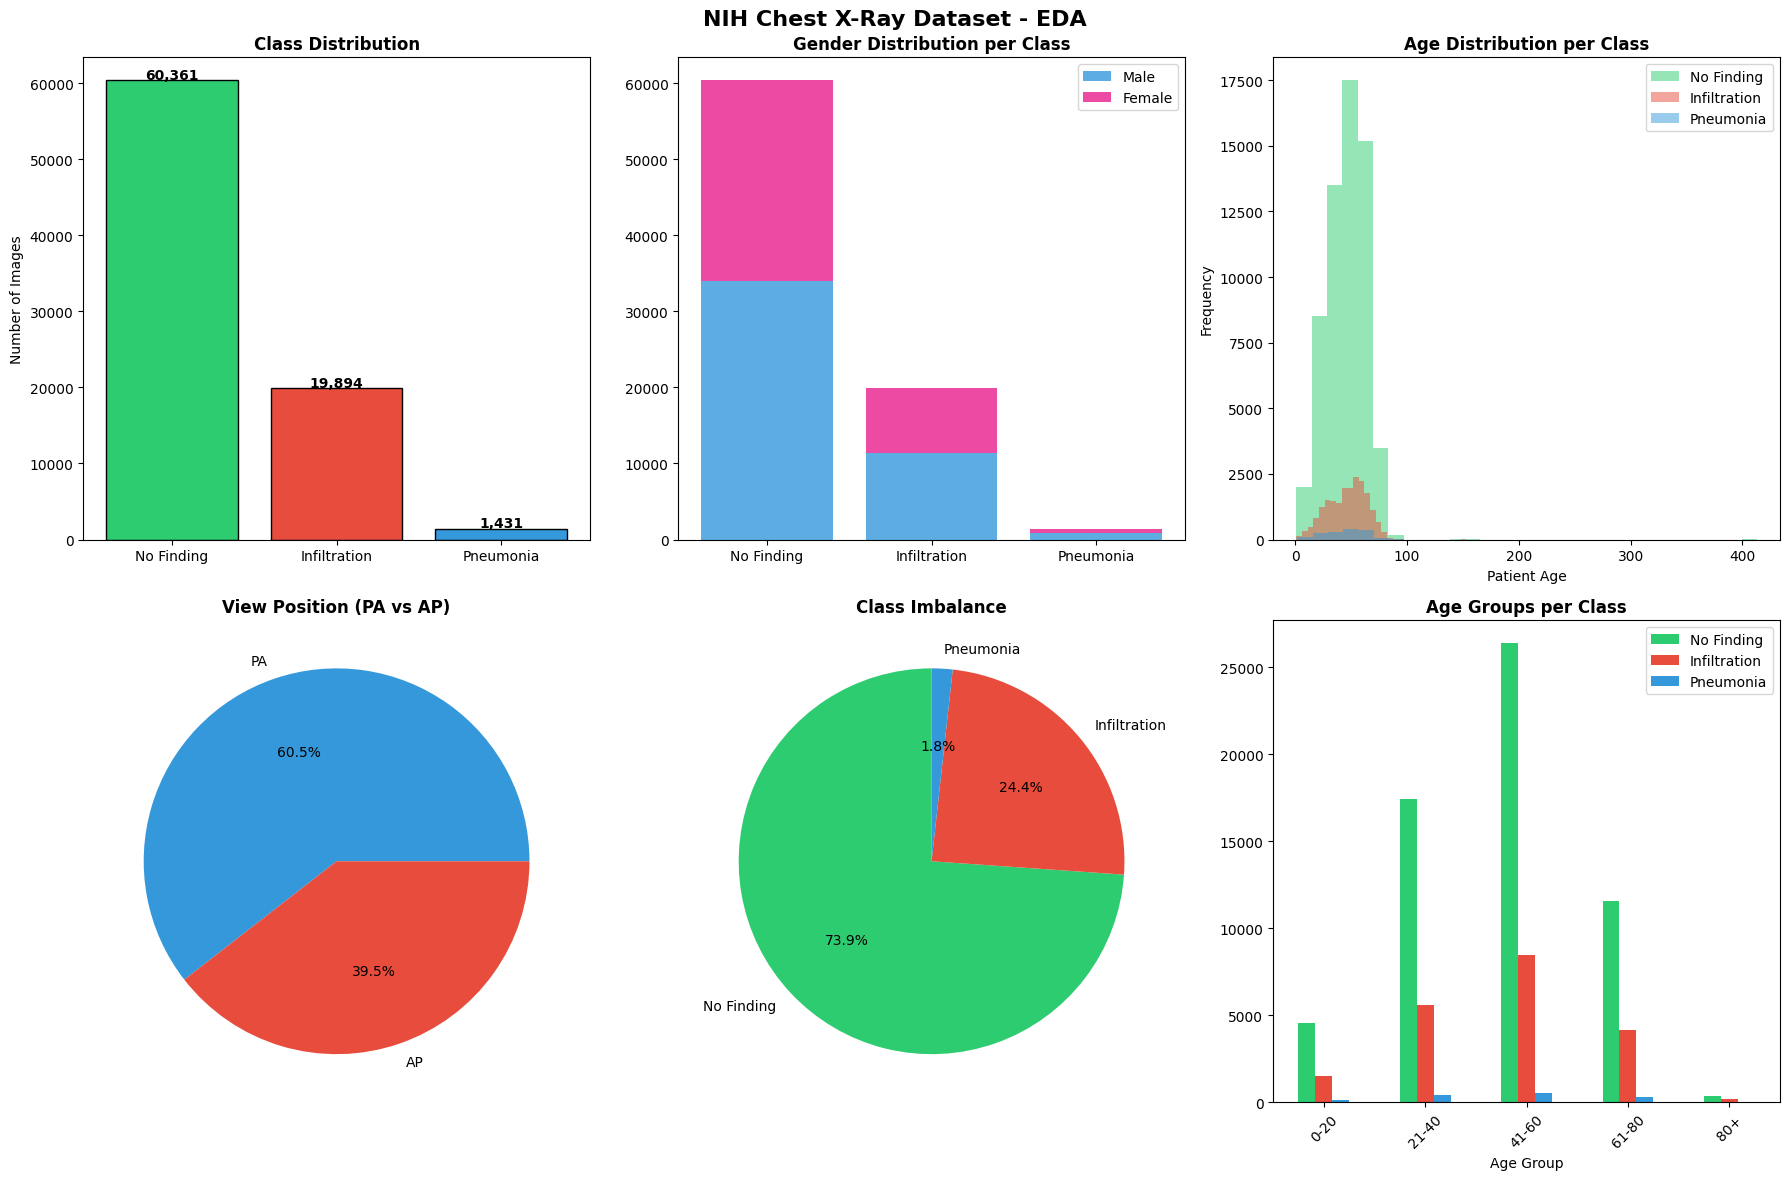

✅ EDA plots saved to Google Drive!


In [ ]:
# ============================================================
# WEEK 2 - EDA
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('NIH Chest X-Ray Dataset - EDA', fontsize=16, fontweight='bold')

# 1. Class Distribution
class_counts = df['Finding Labels'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0,0].bar(['No Finding', 'Infiltration', 'Pneumonia'],
              [df['has_no_finding'].sum(), df['has_infiltration'].sum(), df['has_pneumonia'].sum()],
              color=colors, edgecolor='black')
axes[0,0].set_title('Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Number of Images')
for i, v in enumerate([df['has_no_finding'].sum(), df['has_infiltration'].sum(), df['has_pneumonia'].sum()]):
    axes[0,0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# 2. Gender Distribution per Class
gender_data = {
    'No Finding': df[df['has_no_finding']]['Patient Gender'].value_counts(),
    'Infiltration': df[df['has_infiltration']]['Patient Gender'].value_counts(),
    'Pneumonia': df[df['has_pneumonia']]['Patient Gender'].value_counts()
}
x = range(3)
m_vals = [gender_data[c].get('M', 0) for c in ['No Finding', 'Infiltration', 'Pneumonia']]
f_vals = [gender_data[c].get('F', 0) for c in ['No Finding', 'Infiltration', 'Pneumonia']]
axes[0,1].bar(x, m_vals, label='Male', color='#3498db', alpha=0.8)
axes[0,1].bar(x, f_vals, bottom=m_vals, label='Female', color='#e91e8c', alpha=0.8)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(['No Finding', 'Infiltration', 'Pneumonia'])
axes[0,1].set_title('Gender Distribution per Class', fontweight='bold')
axes[0,1].legend()

# 3. Age Distribution
df[df['has_no_finding']]['Patient Age'].plot(kind='hist', ax=axes[0,2], alpha=0.5, label='No Finding', color='#2ecc71', bins=30)
df[df['has_infiltration']]['Patient Age'].plot(kind='hist', ax=axes[0,2], alpha=0.5, label='Infiltration', color='#e74c3c', bins=30)
df[df['has_pneumonia']]['Patient Age'].plot(kind='hist', ax=axes[0,2], alpha=0.5, label='Pneumonia', color='#3498db', bins=30)
axes[0,2].set_title('Age Distribution per Class', fontweight='bold')
axes[0,2].set_xlabel('Patient Age')
axes[0,2].legend()

# 4. View Position
view_counts = df['View Position'].value_counts()
axes[1,0].pie(view_counts.values, labels=view_counts.index,
              autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
axes[1,0].set_title('View Position (PA vs AP)', fontweight='bold')

# 5. Class Imbalance
total = len(df)
sizes = [df['has_no_finding'].sum(), df['has_infiltration'].sum(), df['has_pneumonia'].sum()]
axes[1,1].pie(sizes, labels=['No Finding', 'Infiltration', 'Pneumonia'],
              autopct='%1.1f%%', colors=colors, startangle=90)
axes[1,1].set_title('Class Imbalance', fontweight='bold')

# 6. Age Groups per Class
df['Age Group'] = pd.cut(df['Patient Age'], bins=[0,20,40,60,80,200],
                          labels=['0-20','21-40','41-60','61-80','80+'])
age_class = df.groupby('Age Group')[['has_no_finding','has_infiltration','has_pneumonia']].sum()
age_class.plot(kind='bar', ax=axes[1,2], color=colors)
axes[1,2].set_title('Age Groups per Class', fontweight='bold')
axes[1,2].set_xlabel('Age Group')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].legend(['No Finding', 'Infiltration', 'Pneumonia'])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ChestXray_Project/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved to Google Drive!")

Chart 1 — Class Distribution
60,361 vs 19,894 vs 1,431 — confirms severe imbalance. Pneumonia is tiny compared to No Finding.

Chart 2 — Gender Distribution

No Finding: ~56% Male, ~44% Female
Infiltration: similar split
Pneumonia: very small but both genders represented
✅ Good for fairness analysis — both genders exist in all classes

Chart 3 — Age Distribution

Most patients are between 20-80 years old
Peak around 40-60 years
There are some outliers showing ages 200-400 — those are data entry errors in the NIH dataset we should handle

Chart 4 — View Position

PA: 60.5% ✅
AP: 39.5%
We have more PA views which is good — PA is higher quality

Chart 5 — Class Imbalance

No Finding: 73.9%
Infiltration: 24.4%
Pneumonia: 1.8% — barely visible!
This visually screams why we need weighted loss

Chart 6 — Age Groups per Class

41-60 is the dominant age group across all classes
Very few patients in 0-20 and 80+ groups
Pneumonia barely visible across all age groups

In [ ]:
# Checking Patient's Age Outliers
print("Age outliers:")
print(df[df['Patient Age'] > 120]['Patient Age'].value_counts())
print(f"\nTotal outliers: {len(df[df['Patient Age'] > 120])}")

Age outliers:
Patient Age
412    2
148    2
155    2
149    1
150    1
151    1
411    1
413    1
153    1
Name: count, dtype: int64

Total outliers: 12


In [ ]:
# Document the outliers
print("Outlier details:")
print(df[df['Patient Age'] > 120][['Image Index', 'Patient Age', 'Finding Labels', 'Patient Gender']])

# Fix: cap age at 120 (replace outliers with median age)
median_age = df[df['Patient Age'] <= 120]['Patient Age'].median()
print(f"\nMedian age (excluding outliers): {median_age}")

# Replace outlier ages with median
df['Patient Age Clean'] = df['Patient Age'].apply(lambda x: median_age if x > 120 else x)

print(f"\nOutliers before fix: {len(df[df['Patient Age'] > 120])}")
print(f"Outliers after fix: {len(df[df['Patient Age Clean'] > 120])}")
print(f"\n✅ Age outliers handled! Using 'Patient Age Clean' column going forward.")

# Save the cleaned CSV back to Drive
df.to_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv', index=False)
print("✅ Cleaned CSV saved to Google Drive!")

Outlier details:
            Image Index  Patient Age      Finding Labels Patient Gender
15419  00005567_000.png          412  Effusion|Pneumonia              M
35225  00012238_010.png          148          No Finding              M
40524  00013950_000.png          148          No Finding              M
42652  00014520_026.png          150   Infiltration|Mass              M
45591  00015558_000.png          149          No Finding              M
56718  00019346_000.png          151        Infiltration              F
60994  00020900_002.png          411          No Finding              M
62067  00021275_003.png          413          No Finding              F
65754  00022811_000.png          412          No Finding              M
69372  00025206_000.png          153   Infiltration|Mass              M
73227  00026871_000.png          155          No Finding              F
75718  00027989_000.png          155          No Finding              M

Median age (excluding outliers): 47.0

Outlier

# Findings in Outliers
Interesting observations from the outlier details:

All outliers are Male except 3 (rows 56718, 62067, 73227)
Ages like 411, 412, 413 are clearly someone typing an extra digit — probably meant 41, 42, 43

Ages like 148, 149, 150, 151 likely meant 48, 49, 50, 51 — same typo pattern
One outlier has Effusion|Pneumonia — a multi-label case
Two have Infiltration|Mass — also multi-label

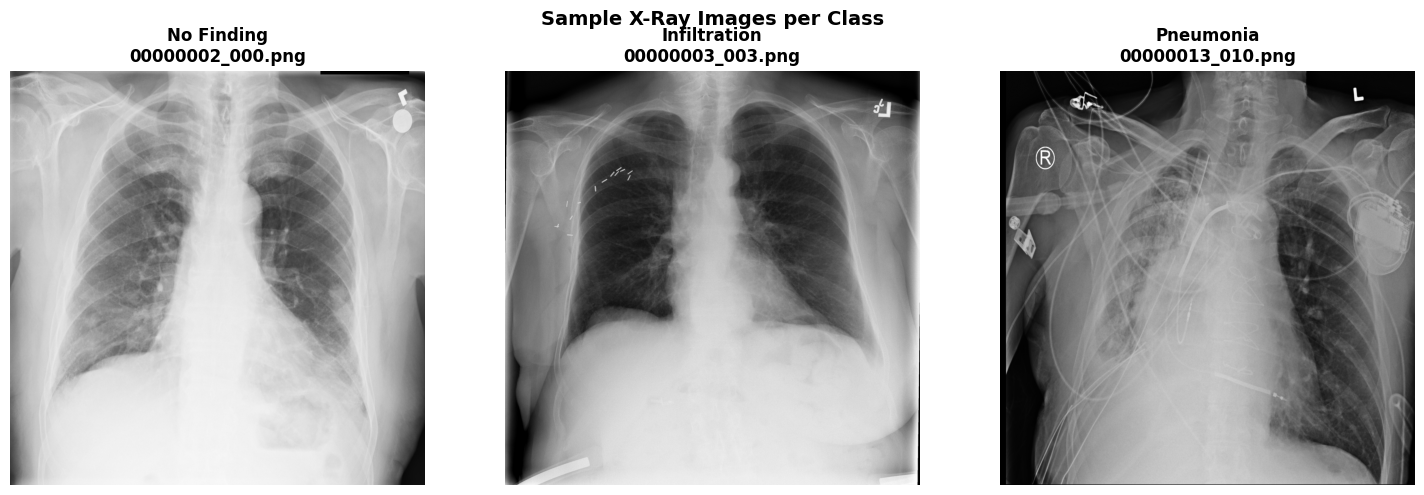

✅ Sample images saved to Drive!


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Path to images in Drive
images_path = '/content/drive/MyDrive/ChestXray_Project/images'

# Get sample images for each class
samples = {
    'No Finding': df[df['has_no_finding'] == True]['Image Index'].iloc[0],
    'Infiltration': df[df['has_infiltration'] == True]['Image Index'].iloc[0],
    'Pneumonia': df[df['has_pneumonia'] == True]['Image Index'].iloc[0]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sample X-Ray Images per Class', fontsize=14, fontweight='bold')

for idx, (label, img_name) in enumerate(samples.items()):
    # Search for the image in subfolders
    for root, dirs, files in os.walk(images_path):
        if img_name in files:
            img_path = os.path.join(root, img_name)
            break

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{label}\n{img_name}', fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ChestXray_Project/sample_images.png', dpi=150)
plt.show()
print("✅ Sample images saved to Drive!")

# What you're seeing:
No Finding (left)

Clear, dark lung fields
Clean, well-defined borders
Uniform texture throughout
This is what a healthy chest X-ray looks like

Infiltration (middle)

Noticeably hazier and cloudier
Less defined lung borders
You can see whitish patches scattered around
The lungs look "filled" compared to No Finding

Pneumonia (right)

Much brighter/whiter areas — especially on the right side
Dense consolidation visible
The lung fields are significantly more opaque
This is the most visually distinct from No Finding

In [4]:
# Mount Drive and load dependencies
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Load filtered CSV
df = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
images_path = '/content/drive/MyDrive/ChestXray_Project/images'

print("✅ Libraries loaded!")
print(f"✅ Dataset loaded: {len(df)} rows")

Mounted at /content/drive
✅ Libraries loaded!
✅ Dataset loaded: 81081 rows


In [ ]:
# ============================================================
# WEEK 3 - OpenCV Preprocessing Pipeline
# ============================================================

def find_image(img_name, images_path):
    """Find image file in subfolders"""
    for root, dirs, files in os.walk(images_path):
        if img_name in files:
            return os.path.join(root, img_name)
    return None

def preprocess_xray(img_path, target_size=(224, 224)):
    """
    Full OpenCV preprocessing pipeline for chest X-rays
    Steps: Load → CLAHE → Denoise → Resize
    """
    # Step 1 - Load image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Step 2 - CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img)

    # Step 3 - Gaussian denoising
    img_denoised = cv2.GaussianBlur(img_clahe, (3, 3), 0)

    # Step 4 - Resize to 224x224
    img_resized = cv2.resize(img_denoised, target_size)

    return {
        'original': img,
        'clahe': img_clahe,
        'denoised': img_denoised,
        'final': img_resized
    }

print("✅ Preprocessing function defined!")

✅ Preprocessing function defined!


 We used the pre-processing pipeline above for analysis and visualization because it returns all intermediate steps — original, clahe, denoised, final. You used it to compare and see what each preprocessing step was doing to the image.

Take a raw X-ray, enhance its contrast so lung patterns are clearer, remove noise so the model doesn't learn from random speckles, then resize it to the standard size the model expects.

Slide a tiny 3x3 window across every pixel in the image, replace each pixel with the average of itself and its 8 neighbors — noise disappears because random speckles get averaged out with their normal surroundings

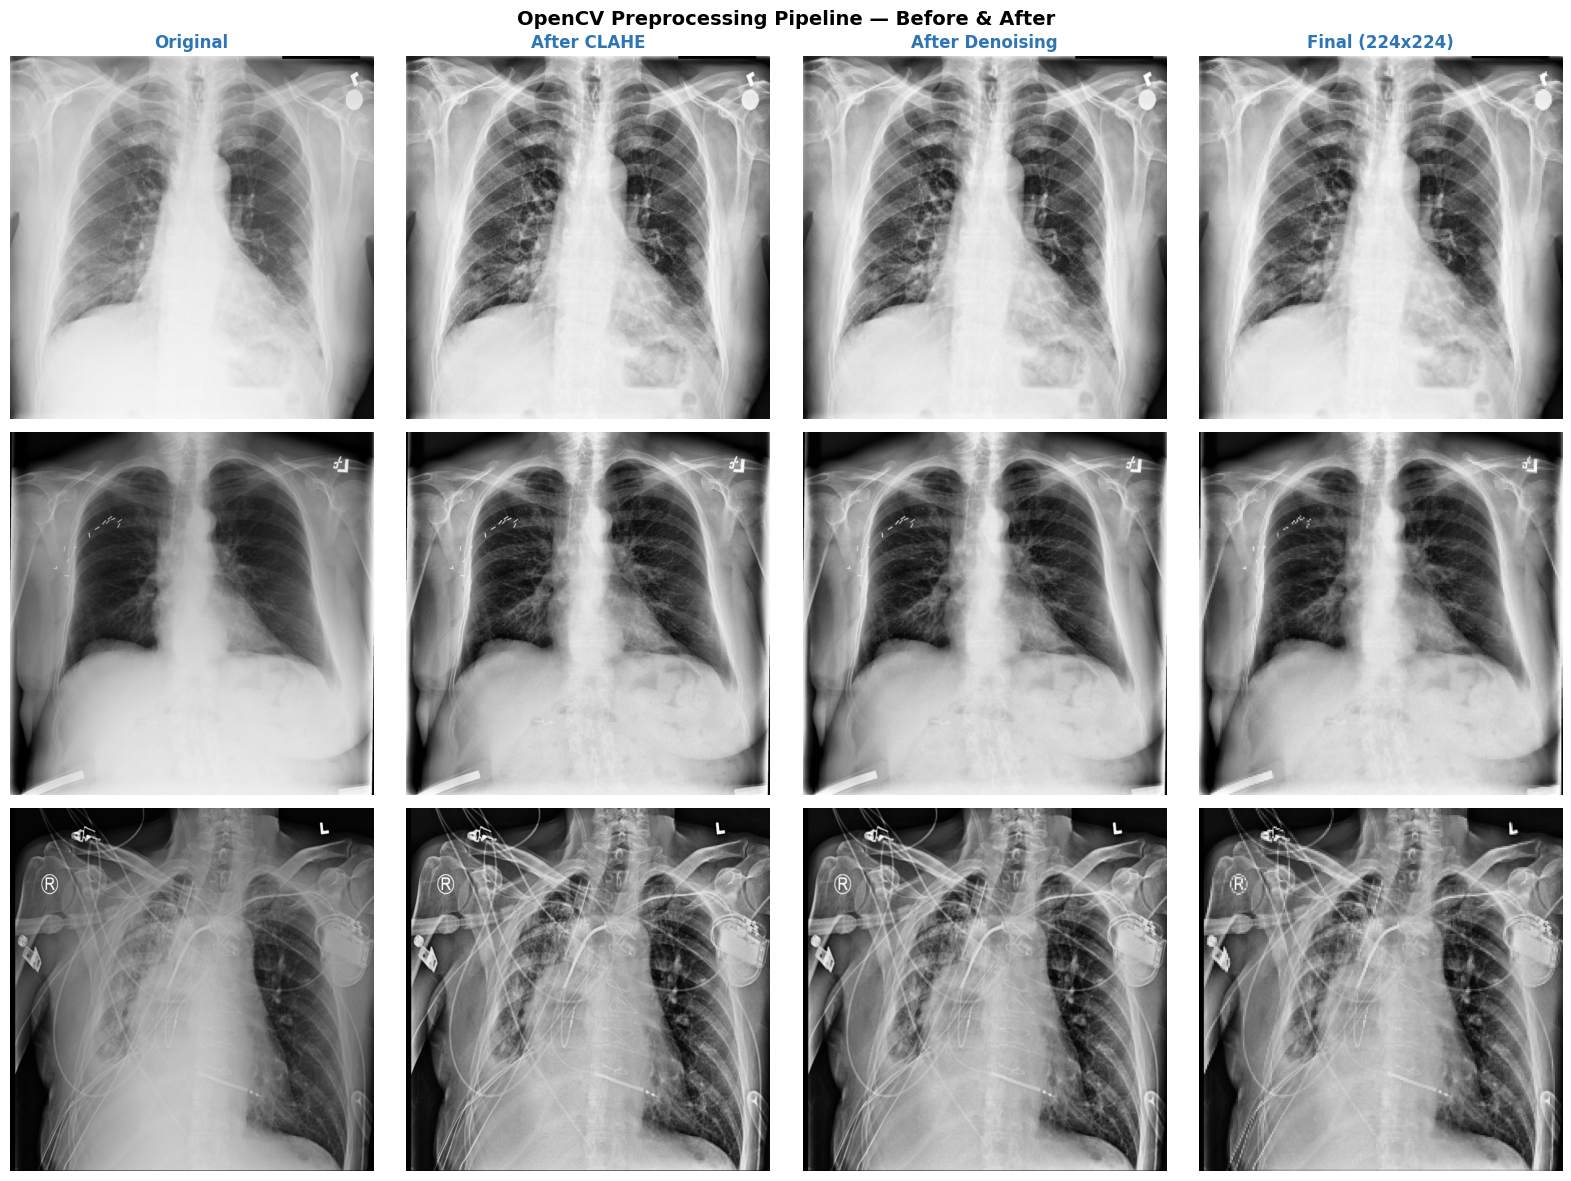

✅ Preprocessing comparison saved to Drive!


In [ ]:
# ============================================================
# Test preprocessing on one image from each class
# ============================================================

classes = {
    'No Finding': df[df['has_no_finding'] == True]['Image Index'].iloc[0],
    'Infiltration': df[df['has_infiltration'] == True]['Image Index'].iloc[0],
    'Pneumonia': df[df['has_pneumonia'] == True]['Image Index'].iloc[0]
}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('OpenCV Preprocessing Pipeline — Before & After',
             fontsize=14, fontweight='bold')

col_titles = ['Original', 'After CLAHE', 'After Denoising', 'Final (224x224)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold', color='#2E75B6')

for row, (label, img_name) in enumerate(classes.items()):
    img_path = find_image(img_name, images_path)
    result = preprocess_xray(img_path)

    stages = ['original', 'clahe', 'denoised', 'final']
    for col, stage in enumerate(stages):
        axes[row][col].imshow(result[stage], cmap='gray')
        axes[row][col].set_ylabel(label, fontweight='bold') if col == 0 else None
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ChestXray_Project/preprocessing_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preprocessing comparison saved to Drive!")

**Week 4**

In [3]:
# Install Albumentations (Colab)
!pip install -q albumentations

import os, re, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

**albumentations**

A fast, flexible image augmentation library built on top of OpenCV. It applies transforms directly to NumPy arrays (the same format your OpenCV pipeline already produces), so there's no format conversion step.

**albumentations.pytorch.ToTensorV2**

A special Albumentations transform that converts a NumPy H×W×C image into a PyTorch C×H×W tensor. It's the bridge between the OpenCV/Albumentations world and the PyTorch world.

**torch.utils.data.WeightedRandomSampler**

A PyTorch DataLoader sampler that draws training examples with non-uniform probability — giving minority classes (like Pneumonia) a higher chance of being selected each batch.

You assign each training sample a weight proportional to 1/class_size. The sampler then draws with replacement so that over an epoch, all classes appear roughly equally often — without you ever duplicating or deleting any image files. It works at the DataLoader level, meaning it plugs in as the sampler= argument and replaces shuffle=True.

**torch.nn.CrossEntropyLoss(weight=...)**

The standard multi-class classification loss, but with an optional weight tensor that penalizes misclassifying rare classes more heavily than common ones.

Without weights, the loss is dominated by the majority class (No Finding, 60k samples). With inverse-frequency weights, a wrong Pneumonia prediction contributes ~42× more loss than a wrong No Finding prediction — forcing the model to care about rare classes during backpropagation. This complements WeightedRandomSampler: the sampler controls what the model sees; the loss controls how hard it gets penalized.

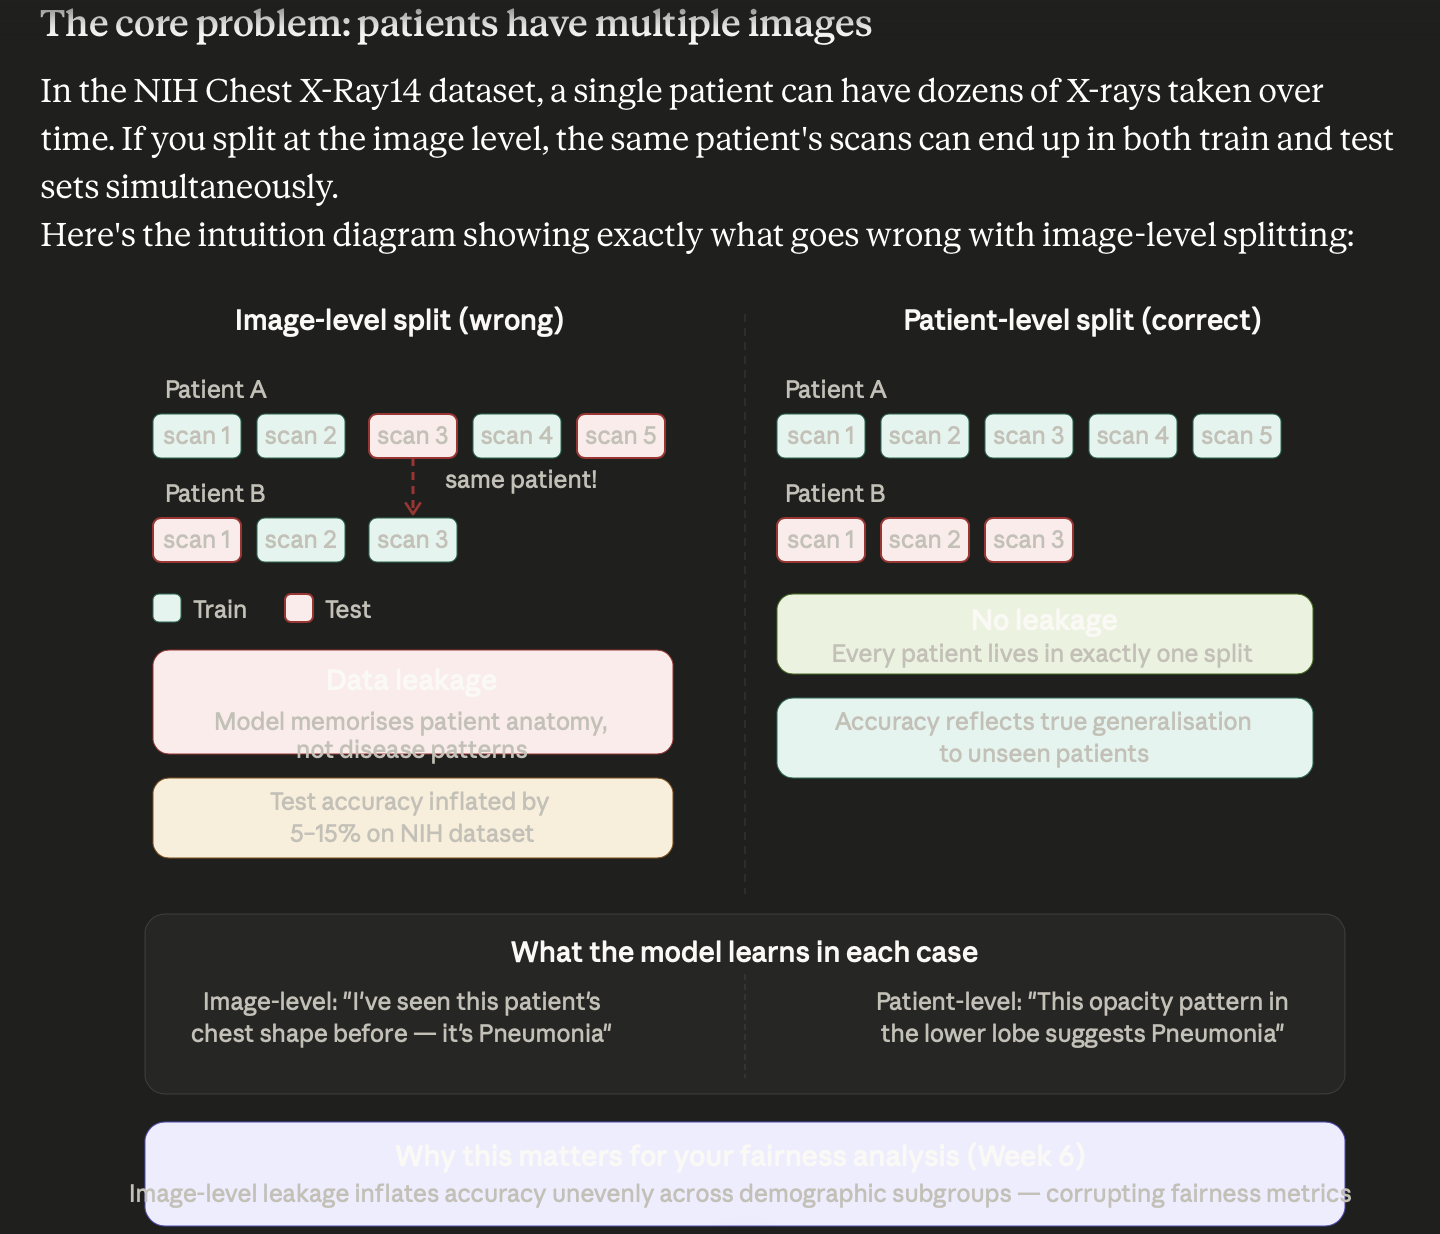

There are two different things a model could be learning from Patient A's chest X-ray:

"This opacity pattern in the lower lobe, with this density and shape, is Pneumonia" — the actual disease signal
"This particular rib cage, this heart size, this diaphragm curve — I've seen this exact chest before" — the patient's identity

Both of these "work" during training. The model can't tell the difference between them. It will just use whatever signal best reduces its loss — and patient anatomy is an incredibly strong, consistent signal because it doesn't change scan to scan.
Think of it like a student preparing for an exam. The ideal scenario is:

Study from one set of questions, get tested on completely new questions → proves they understood the subject

What image-level splitting accidentally creates is:

Study from questions 1, 3, 4 of a patient's exams, get tested on question 2 from that same exam → they might just recognize the handwriting and paper format, not the content

The model is genuinely learning, genuinely detecting — the issue is what it's detecting. When you then deploy this model in a hospital on a patient it has truly never seen before, that anatomical familiarity signal disappears entirely. Only the true disease signal remains. And if the model leaned on anatomy as a shortcut during training, its real-world performance collapses.
Patient-level splitting simulates exactly what deployment looks like: every patient in the test set is a stranger the model has never encountered in any form.

In [5]:
DATA_ROOT = Path("/content/drive/MyDrive/ChestXray_Project")
IMG_DIR   = DATA_ROOT / "images"
CSV_PATH  = DATA_ROOT / "filtered_labels.csv"

TARGET_LABELS = {"No Finding": 0, "Infiltration": 1, "Pneumonia": 2}

df = pd.read_csv(CSV_PATH)

# Keep only single-label rows matching our 3 classes
df = df[df["Finding Labels"].isin(TARGET_LABELS.keys())].copy()
df["label"]      = df["Finding Labels"].map(TARGET_LABELS)
df["patient_id"] = df["Image Index"].str.extract(r"(\d+)_").astype(int)

print(f"Filtered dataset: {len(df):,} images")
print(df["Finding Labels"].value_counts())

Filtered dataset: 70,230 images
Finding Labels
No Finding      60361
Infiltration     9547
Pneumonia         322
Name: count, dtype: int64


**Patient-Level Stratified Split (critical for fairness)**

Patient-level splitting is essential: the same patient's X-rays must not appear in both train and test sets, or your model learns patient-specific features instead of pathology.

In [6]:
def patient_stratified_split(df, val_frac=0.15, test_frac=0.15, seed=42):
    """
    Split at the patient level — all images for a given patient
    land in exactly one of train / val / test.
    Stratifies so class proportions are preserved in every split.
    """
    # One row per patient: use their most common label
    patient_df = (
        df.groupby("patient_id")["label"]
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={"label": "patient_label"})
    )

    # First: carve out test
    trainval_pids, test_pids = train_test_split(
        patient_df["patient_id"],
        test_size=test_frac,
        stratify=patient_df["patient_label"],
        random_state=seed,
    )

    # Then: split trainval into train / val
    trainval_df = patient_df[patient_df["patient_id"].isin(trainval_pids)]
    train_pids, val_pids = train_test_split(
        trainval_df["patient_id"],
        test_size=val_frac / (1 - test_frac),
        stratify=trainval_df["patient_label"],
        random_state=seed,
    )

    train_df = df[df["patient_id"].isin(train_pids)].reset_index(drop=True)
    val_df   = df[df["patient_id"].isin(val_pids)].reset_index(drop=True)
    test_df  = df[df["patient_id"].isin(test_pids)].reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = patient_stratified_split(df)

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split["Finding Labels"].value_counts()
    print(f"\n{name}: {len(split):,} images | {split['patient_id'].nunique():,} patients")
    print(counts.to_string())

# Verify zero patient overlap (should all be 0)
assert len(set(train_df.patient_id) & set(val_df.patient_id))  == 0, "Train/Val leak!"
assert len(set(train_df.patient_id) & set(test_df.patient_id)) == 0, "Train/Test leak!"
assert len(set(val_df.patient_id)   & set(test_df.patient_id)) == 0, "Val/Test leak!"
print("\n✓ No patient overlap between splits")


Train: 49,255 images | 18,689 patients
Finding Labels
No Finding      42421
Infiltration     6607
Pneumonia         227

Val: 10,288 images | 4,005 patients
Finding Labels
No Finding      8825
Infiltration    1417
Pneumonia         46

Test: 10,687 images | 4,005 patients
Finding Labels
No Finding      9115
Infiltration    1523
Pneumonia         49

✓ No patient overlap between splits


What we did is first we shrunk the data at patient level to get one record of each patient then we used stratify to help us in splitting the patients equally after that we filtered the dataset to different train_df val_df and test_df according to those patient ids and placed their images with them.

70,230 images ----->

Shrink to 26,000 patients (one row each, mode label) ----->

Split those patients into train/val/test using stratify ----->

Filter original 70,230 images using those patient IDs ----->

train_df (49,255) | val_df (10,288) | test_df (10,687)

And the key reason we did it in that order — shrink first, split, then filter back — is so that every patient lands in exactly one group, making data leakage impossible.

**Albumentations Transform Pipelines**

The train pipeline applies geometric and intensity augmentations that are clinically realistic for chest X-rays. Val/Test use only the same normalization as training.

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)   # transfer learning baseline
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transforms = A.Compose([
    # Geometric — mild, radiologically plausible
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.6),
    A.Affine(translate_percent=0.05, scale=(0.95, 1.05), p=0.4),

    # Intensity — simulate exposure variation
    A.RandomBrightnessContrast(brightness_limit=0.15,
                               contrast_limit=0.15, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    # Regularization — simulate occlusion / rib overlap
    A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(8, 16),
                    hole_width_range=(8, 16), fill=0, p=0.3),

    # Elastic deformation — subtle tissue-level variation
    A.ElasticTransform(alpha=1, sigma=50, p=0.2),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_test_transforms = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

Above code builds two image transformation pipelines.

train_transforms applies random augmentations like flipping, rotating, brightness changes and dropout patches to training images — simulating real world variation in X-ray machines, patient positioning and tissue appearance, helping the model generalize better.

val_test_transforms applies only normalization to val and test images keeping evaluation honest.

Both pipelines normalize using ImageNet mean and std values to prepare images for the pretrained model we will use later.

**Custom Dataset with OpenCV Preprocessing**

In [21]:
"""
    Applies the Week 3 OpenCV pipeline (CLAHE + Gaussian denoise + resize)
    then the Albumentations augmentation transforms.
    """
class ChestXrayDataset(Dataset):
  def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

  def _preprocess(self, img_gray):
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img   = clahe.apply(img_gray)
        img   = cv2.GaussianBlur(img, (3, 3), 0)
        img   = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)
        img   = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        return img

  def __len__(self):
        return len(self.df)

  def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = file_to_path[row["Image Index"]]  # use lookup dict
        img_gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img_gray is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = self._preprocess(img_gray)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(row["label"], dtype=torch.long)

In [13]:
import os

IMG_DIR = '/content/drive/MyDrive/ChestXray_Project/images'
existing_files = set()
file_to_path = {}

for root, dirs, files in os.walk(IMG_DIR):
    for filename in files:
        if filename.endswith('.png') and filename.startswith('000'):
            existing_files.add(filename)
            file_to_path[filename] = os.path.join(root, filename)

print(f"Total X-ray images found: {len(existing_files)}")

Total X-ray images found: 82454


In [14]:
df = df[df["Image Index"].isin(existing_files)].reset_index(drop=True)
print(f"Working dataset: {len(df)} images")
print(df["Finding Labels"].value_counts())

train_df, val_df, test_df = patient_stratified_split(df)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Working dataset: 70230 images
Finding Labels
No Finding      60361
Infiltration     9547
Pneumonia         322
Name: count, dtype: int64

Train: 49255 | Val: 10288 | Test: 10687


**Class Imbalance Handling**

**Two complementary strategies — use both simultaneously for Pneumonia's extreme minority ratio (~42:1 vs No Finding).**

In [22]:
# ── Strategy A: Compute weighted CrossEntropy loss weights ──────────────────
label_counts = np.array([
    (train_df["label"] == c).sum() for c in range(len(TARGET_LABELS))
])
class_weights = 1.0 / label_counts
class_weights = class_weights / class_weights.sum() * len(TARGET_LABELS)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("Class weights for CrossEntropy loss:")
for cls, w in zip(TARGET_LABELS.keys(), class_weights):
    print(f"  {cls}: {w:.4f}")


# ── Strategy B: WeightedRandomSampler (oversampling) ───────────────────────
sample_weights = class_weights[train_df["label"].values]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_df),
    replacement=True,
)

Class weights for CrossEntropy loss:
  No Finding: 0.0154
  Infiltration: 0.0991
  Pneumonia: 2.8854


CrossEntropy Loss is the standard way of measuring how wrong a classification model is. It compares what the model predicted against the correct answer and produces a single number — the higher the number the more wrong the model is.

For example if the correct answer is Pneumonia but the model predicted No Finding with 80% confidence, CrossEntropy produces a big loss number. If the model predicted Pneumonia with 90% confidence, it produces a tiny loss number.

Regular CrossEntropy loss treats a wrong Pneumonia prediction and a wrong No Finding prediction exactly the same. It does not care which class was missed.
Weighted CrossEntropy says — these classes are not equal in your dataset. No Finding has 42,421 samples and Pneumonia has only 227. So a wrong Pneumonia prediction should hurt the model much more than a wrong No Finding prediction, because the model barely gets to see Pneumonia during training and we need it to take those rare cases seriously.

The weights are the mechanism that creates that difference in penalty. That is the entire idea behind weighted CrossEntropy loss — same loss function, but rare classes hit harder.


Normally when PyTorch builds a batch it picks images randomly — completely random. With 49,255 training images where 42,421 are No Finding and only 227 are Pneumonia, a random batch of 32 images would likely have 29 No Finding, 3 Infiltration and 0 Pneumonia. The model barely ever sees Pneumonia.

WeightedRandomSampler changes how batches are built. Instead of pure random it picks images based on their weights. Pneumonia images have a much higher weight so they get picked more often. A batch now might have 10 No Finding, 11 Infiltration and 11 Pneumonia — much more balanced.

**Build DataLoaders**

In [24]:
# This cell builds the DataLoaders that feed images into the model in batches.

# model sees 32 images at a time instead of all 49,255 at once
BATCH_SIZE  = 32

# 2 background workers preload the next batch while model trains
NUM_WORKERS = 2

# Three datasets are created from cell 5 ChestXrayDataset:

train_ds = ChestXrayDataset(train_df, transform=train_transforms)
# gets full augmentation transforms (flips, rotations etc.)

val_ds   = ChestXrayDataset(val_df, transform=val_test_transforms)
# gets only normalization, no augmentation

test_ds  = ChestXrayDataset(test_df, transform=val_test_transforms)
# gets only normalization, no augmentation

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler,      # WeightedRandomSampler
                          num_workers=NUM_WORKERS, pin_memory=True)
# uses WeightedRandomSampler to oversample Pneumonia images. No shuffle because sampler handles randomness.

val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
# shuffle=False for consistent evaluation results every run

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 1540
Val   batches : 322
Test  batches : 334


**Sanity Check & Augmentation Visualization**

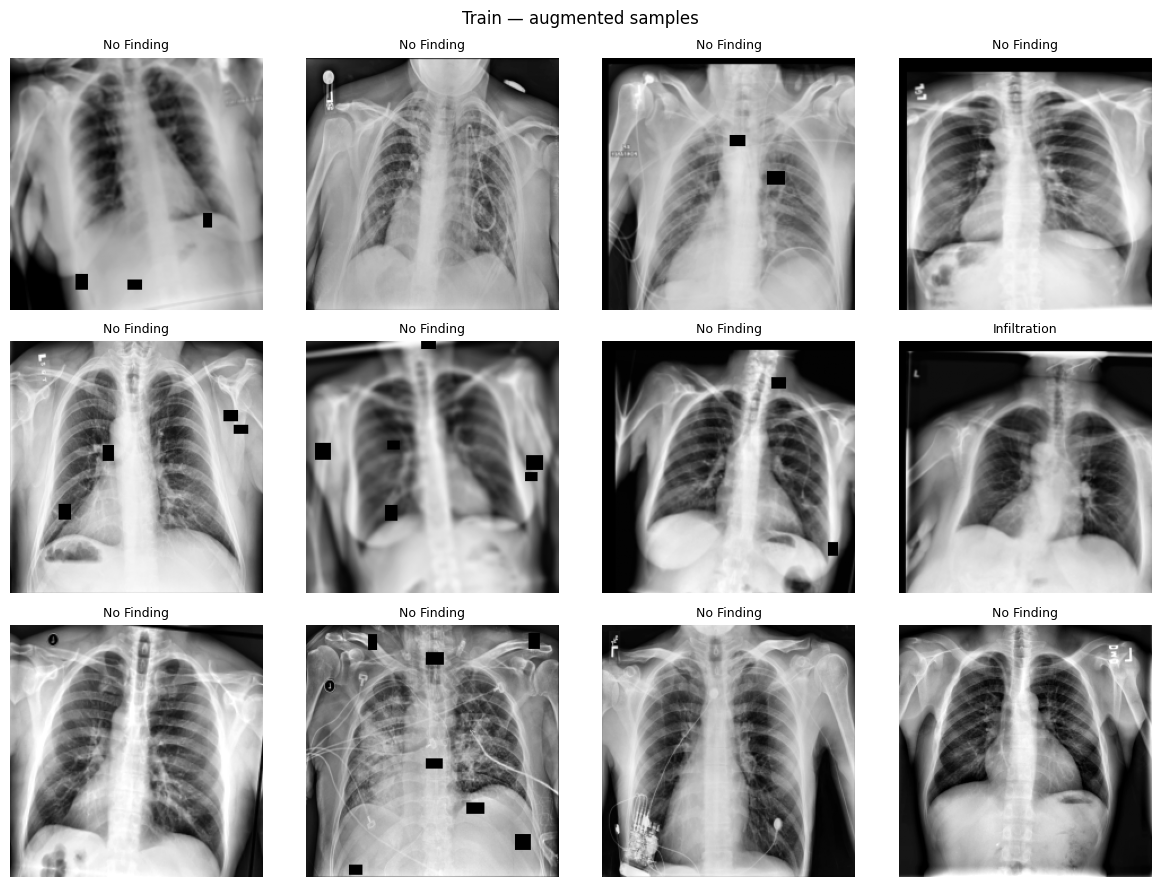

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Sampled class distribution (first 2000 examples):
  No Finding: 679
  Infiltration: 682
  Pneumonia: 655


In [25]:
def show_augmented_grid(dataset, n_rows=3, n_cols=4, title="Augmentation samples"):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    idx = random.choices(range(len(dataset)), k=n_rows * n_cols)

    for ax, i in zip(axes.flat, idx):
        img_t, label = dataset[i]
        # Un-normalize for display
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img  = (img_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img[:, :, 0], cmap="gray")
        ax.set_title(list(TARGET_LABELS.keys())[label.item()], fontsize=9)
        ax.axis("off")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(DATA_ROOT / "week4_augmentation_grid.png", dpi=150)
    plt.show()

show_augmented_grid(train_ds, title="Train — augmented samples")

# Verify sampler re-balances class frequencies
sample_labels = []
for imgs, labels in train_loader:
    sample_labels.extend(labels.tolist())
    if len(sample_labels) >= 2000:
        break

from collections import Counter
print("\nSampled class distribution (first 2000 examples):")
for cls, idx in TARGET_LABELS.items():
    print(f"  {cls}: {Counter(sample_labels)[idx]}")

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
# Search for the notebook
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.ipynb'):
            print(os.path.join(root, f))

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/Copy of In-class activity_2(Python Libraries).ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of In-class activity3.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of In-class activity 4.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of In-class activity 9 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of In-class activity 9.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of DSF-Activity6.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of DSF-Mini_Project.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Handout1.ipynb
/content/drive/MyDrive/Colab Notebooks/Another copy of Handout2(1).ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Handout_3.ipynb
/content/drive/MyDrive/Colab Notebooks/Another copy of Mini-Project 1 .ipynb
/content/drive/MyDrive/Colab Notebooks/svm.ipynb
/content/drive/My

In [1]:
import base64, requests

GITHUB_TOKEN = "YOUR_GITHUB_TOKEN"
REPO = "daniyal-ahmed-khan/Capstone"

headers = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github.v3+ajson"
}

def push_file(file_path, github_path, commit_message, binary=False):
    # Read file
    mode = 'rb' if binary else 'r'
    with open(file_path, mode) as f:
        content = f.read()

    # Get SHA if file exists
    response = requests.get(
        f"https://api.github.com/repos/{REPO}/contents/{github_path}",
        headers=headers
    )
    sha = response.json().get("sha", None)

    # Encode and push
    encoded = base64.b64encode(content if binary else content.encode()).decode()
    payload = {"message": commit_message, "content": encoded}
    if sha:
        payload["sha"] = sha

    result = requests.put(
        f"https://api.github.com/repos/{REPO}/contents/{github_path}",
        headers=headers,
        json=payload
    )
    status = "✓ Done!" if result.status_code in [200, 201] else f"✗ Failed: {result.json()}"
    print(f"{github_path}: {status}")

# Push notebook
push_file(
    '/content/drive/MyDrive/ChestXray_Project/Capstone.ipynb',
    'notebooks/Capstone.ipynb',
    'Week 4: Augmentation, patient-level splits, class imbalance handling'
)

# Push augmentation grid
push_file(
    '/content/drive/MyDrive/ChestXray_Project/week4_augmentation_grid.png',
    'results/week4_augmentation_grid.png',
    'Week 4: Add augmentation grid visualization',
    binary=True
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ChestXray_Project/Capstone.ipynb'